# Resume Categorization with Streamlit and Explainable NLP

This notebook builds a small Streamlit app to classify resumes from `Resume.csv`, explains model decisions, and surfaces the language that best predicts resume categories. It trains a lightweight text model (TF-IDF + linear classifier), evaluates it, inspects feature importances, and generates a ready-to-run `streamlit_app.py`.


## Setup
- Uses pandas, scikit-learn, shap, matplotlib, seaborn, streamlit, joblib.
- If needed, install with: `pip install pandas scikit-learn shap matplotlib seaborn streamlit joblib`.
- The notebook samples the data for quick runs; adjust `sample_frac` if you want full training.


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

base_path = Path("/Users/fanxu/XAI")
resume_path = base_path / "Resume.csv"


In [19]:
# Load data
raw = pd.read_csv(resume_path)
print(raw.head()[["ID", "Category"]])
print("\nColumns:", raw.columns.tolist())
print(f"Total rows: {len(raw):,}")

# Basic cleaning
raw = raw[["Resume_str", "Category"]].rename(columns={"Resume_str": "text", "Category": "label"})
raw = raw.dropna(subset=["text", "label"]).reset_index(drop=True)
raw["text"] = raw["text"].str.replace("\s+", " ", regex=True).str.strip()

label_counts = raw["label"].value_counts()
print("\nLabel distribution:\n", label_counts)


<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/var/folders/p9/g53kwws96012dz5gy8wnx12m0000gn/T/ipykernel_29288/2729014314.py:10: SyntaxWarning: invalid escape sequence '\s'
  raw["text"] = raw["text"].str.replace("\s+", " ", regex=True).str.strip()


         ID Category
0  16852973       HR
1  22323967       HR
2  33176873       HR
3  27018550       HR
4  17812897       HR

Columns: ['ID', 'Resume_str', 'Resume_html', 'Category']
Total rows: 2,484

Label distribution:
 label
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


In [20]:
# Optional sampling for faster iteration
sample_frac = 0.25  # set to 1.0 for full dataset
if sample_frac < 1.0:
    data = raw.sample(frac=sample_frac, random_state=42)
else:
    data = raw.copy()

train_df, test_df = train_test_split(data, test_size=0.2, stratify=data["label"], random_state=42)
print(f"Training: {len(train_df)} | Test: {len(test_df)}")


Training: 496 | Test: 125


In [21]:
# Build pipeline: TF-IDF + Logistic Regression
pipeline = Pipeline(
    [
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english")),
        ("clf", LogisticRegression(max_iter=200, n_jobs=-1)),
    ]
)

pipeline.fit(train_df["text"], train_df["label"])
print("Model trained.")


Model trained.


/Users/fanxu/XAI/myenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


                        precision    recall  f1-score   support

            ACCOUNTANT       0.50      0.83      0.62         6
              ADVOCATE       0.50      0.71      0.59         7
           AGRICULTURE       0.00      0.00      0.00         3
               APPAREL       0.00      0.00      0.00         5
                  ARTS       0.00      0.00      0.00         5
            AUTOMOBILE       0.00      0.00      0.00         2
              AVIATION       1.00      0.67      0.80         6
               BANKING       1.00      0.80      0.89         5
  BUSINESS-DEVELOPMENT       0.55      1.00      0.71         6
                  CHEF       0.80      0.67      0.73         6
          CONSTRUCTION       0.80      1.00      0.89         8
            CONSULTANT       0.00      0.00      0.00         5
              DESIGNER       0.71      0.83      0.77         6
         DIGITAL-MEDIA       1.00      0.33      0.50         6
           ENGINEERING       0.60      

/Users/fanxu/XAI/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/fanxu/XAI/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/fanxu/XAI/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


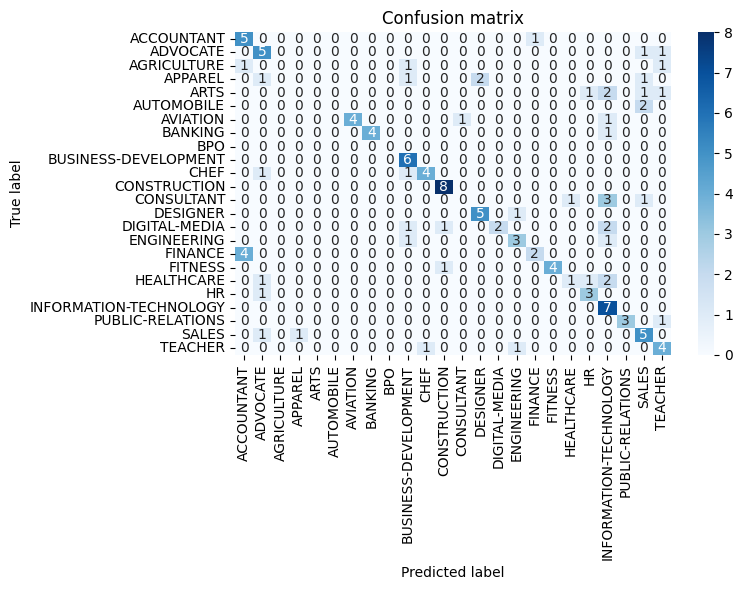

In [22]:
# Evaluation
preds = pipeline.predict(test_df["text"])
print(classification_report(test_df["label"], preds))

cm = confusion_matrix(test_df["label"], preds, labels=pipeline.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(
    pd.DataFrame(cm, index=pipeline.classes_, columns=pipeline.classes_),
    annot=True,
    fmt="d",
    cmap="Blues",
)
plt.title("Confusion matrix")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()


In [23]:
# Top predictive n-grams per class
vectorizer = pipeline.named_steps["tfidf"]
clf = pipeline.named_steps["clf"]
feature_names = np.array(vectorizer.get_feature_names_out())

n_top = 15
rows = []
for idx, label in enumerate(clf.classes_):
    coefs = clf.coef_[idx]
    top_pos = np.argsort(coefs)[-n_top:][::-1]
    top_neg = np.argsort(coefs)[:n_top]
    rows.append(
        {
            "label": label,
            "top_positive_terms": feature_names[top_pos],
            "top_negative_terms": feature_names[top_neg],
        }
    )

importance_df = pd.DataFrame(rows)
importance_df


,label,top_positive_terms,top_negative_terms
0,ACCOUNTANT,"[accounting, accountant, financial, accounts, tax, statements, financial statements, entries, ledger, cash, payroll,...","[service, customer, students, design, team, marketing, engineering, meetings, care, 2013, day, manager, construction..."
1,ADVOCATE,"[advocate, patient, health, care, families, patients, medical, case, billing, legal, illinois, court, service, commu...","[sales, financial, construction, project, marketing, store, engineering, media, finance, design, control, production..."
2,AGRICULTURE,"[iowa, agriculture, ogunade, ibor, loan, students, animal, data, effect, va, science, liberal arts, liberal, 06 2015...","[sales, marketing, business, project, management, company city, design, development, engineering, staff, operations,..."
3,APPAREL,"[store, merchandising, customer, inventory, apparel, merchandise, production, control, customer service, shipping, c...","[financial, business, clients, food, media, accounting, client, patient, finance, construction, marketing, students,..."
4,ARTS,"[students, arts, grade, dental, teacher, language arts, learning, english, school, art, language, medical, english l...","[business, systems, construction, accounting, engineering, payroll, safety, project, employees, care, managed, skill..."
5,AUTOMOBILE,"[legal, automobile, investigator, network, fraud, criminal, criminal justice, justice, vehicle, service manager, pol...","[sales, financial, accounting, students, media, development, new, including, store, marketing, business, constructio..."
6,AVIATION,"[aviation, aircraft, navy, safety, repair, medal, systems, military, material, maintenance, ammunition, aviation sup...","[sales, marketing, construction, company, students, patient, project, financial, media, new, payroll, finance, food,..."
7,BANKING,"[banking, loan, branch, lending, financial, commercial, mortgage, loans, bank, finance, investment, investment banki...","[marketing, design, inventory, media, patient, store, care, construction, training, medical, equipment, safety, pers..."
8,BPO,"[claims, noc, engineer, win, coding, medicare, cpt, icd, skill set, matter expert, expert, incident, technical, work...","[business, state, sales, marketing, city, development, city state, design, accounting, project, quality, students, a..."
9,BUSINESS-DEVELOPMENT,"[business development, sales, marketing, business, development, territory, development manager, region, opportunitie...","[accounting, design, students, safety, project, construction, student, maintenance, production, assistant, hr, gpa, ..."


In [ ]:
# SHAP explanations on a few test examples
sampled_texts = test_df.sample(n=min(20, len(test_df)), random_state=1).reset_index(drop=True)

# Use a simple text masker (whitespace tokenization) to avoid tokenizer dict expectations
text_masker = shap.maskers.Text()
explainer = shap.Explainer(
    pipeline.predict_proba, masker=text_masker, output_names=pipeline.classes_
)
shap_values = explainer(sampled_texts["text"].tolist())

# Visualize the first sample for its predicted class
pred_labels = pipeline.predict(sampled_texts["text"])
target_class_idx = list(pipeline.classes_).index(pred_labels[0])
shap.plots.text(shap_values[0, :, target_class_idx])


PartitionExplainer explainer: 21it [00:12,  1.85s/it]                        


In [27]:
# Persist model and generate Streamlit app
model_path = base_path / "resume_model.joblib"
app_path = base_path / "streamlit_app.py"
joblib.dump(pipeline, model_path)

app_code = """
import streamlit as st
import pandas as pd
import shap
import joblib
from pathlib import Path

st.set_page_config(page_title="Resume Categorizer", layout="wide")
st.title("Resume Categorization with Explanations")

model = joblib.load(Path("{model_path}"))
explainer = shap.Explainer(model)

st.sidebar.header("Input")
resume_text = st.sidebar.text_area("Paste resume text", height=300)

if st.sidebar.button("Predict"):
    if not resume_text.strip():
        st.warning("Please paste a resume.")
    else:
        pred = model.predict([resume_text])[0]
        proba = None
        if hasattr(model, 'predict_proba'):
            proba = model.predict_proba([resume_text])[0]
        st.subheader(f"Predicted category: {pred}")
        if proba is not None:
            prob_df = pd.DataFrame([proba], columns=model.classes_).T
            prob_df.columns = ['probability']
            st.bar_chart(prob_df)

        st.markdown("### Explanation")
        try:
            shap_values = explainer([resume_text])
            st_shap = shap.plots.text(shap_values[0], display=False)
            st.write(st_shap)
        except Exception as e:
            st.error(f"Could not compute SHAP explanation: {e}")

st.markdown("---")
st.caption("Trained with TF-IDF + Logistic Regression on Resume.csv")
"""

# Escape braces in the template except for the model_path placeholder
safe_app_code = (
    app_code.replace("{", "{{").replace("}", "}}").replace("{{model_path}}", "{model_path}")
)
app_path.write_text(safe_app_code.format(model_path=model_path.as_posix()))
print(f"Saved model to {model_path}")
print(f"Wrote Streamlit app to {app_path}")
print("Run: streamlit run streamlit_app.py")


Saved model to /Users/fanxu/XAI/resume_model.joblib
Wrote Streamlit app to /Users/fanxu/XAI/streamlit_app.py
Run: streamlit run streamlit_app.py
